# Fit T2w 
-----------------------
1) Read multi TE T2w images and fit T2 decay over time

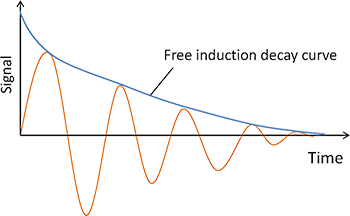

--------------
https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html
curve_fit(f, xdata, ydata, p0=None, sigma=None, absolute_sigma=False, check_finite=None, bounds=(-inf, inf), method=None, jac=None, *, full_output=False, nan_policy=None, **kwargs)

In [34]:
import numpy as np
import os
import nibabel as nib
from scipy.optimize import curve_fit


def t2_decay(TE, S0, T2):
    return S0 * np.exp(-TE / T2)


# ── participants ──
# dict of {label: path_to_4D_nifti}. Add as many subjects as you like.
participants = {
    "sub-10": r"/home/malberti/wks14/temp/FF_DWI_Drift/rawdata/sub-10/ses-01/T2w/sub-10_rh_se_mc_vflip.nii",
    "sub-43": r"/home/malberti/wks14/temp/FF_DWI_Drift/rawdata/sub-43/ses-01/T2w/sub-43_rh_se_mc_vflip.nii",
    "sub-41": r"/home/malberti/wks14/temp/FF_DWI_Drift/rawdata/sub-41/rh_se_mc_vflip/sub-41_rh_se_mc_vflip.nii",
    "sub-45": r"/home/malberti/wks14/temp/FF_DWI_Drift/rawdata/sub-45/ses-01/T2w/sub-45_rh_se_mc_vflip.nii",
    # "sub-XX": r"/path/to/sub-XX_file.nii",
}

TEs = np.array([10, 50, 100, 200, 400, 800, 1600, 3200], dtype=float)  # ms, must match 4th-dim order
out_dir_root = "/home/malberti/Unix_Folders/ESMRMB2026_Manfredi/group_T2_analysis"
os.makedirs(out_dir_root, exist_ok=True)

results = {}  # collect per-subject outputs for a group-level plot at the end

for subj, nifti_path in participants.items():
    print(f"\n=== Processing {subj} ===")
    out_dir = os.path.join(out_dir_root, subj)
    os.makedirs(out_dir, exist_ok=True)

    # ── load 4D data ──
    img = nib.load(nifti_path)
    data = img.get_fdata()  # (X, Y, Z, n_TE)
    affine = img.affine
    print(f"  Loaded data with shape {data.shape}, {len(TEs)} TEs")

    X, Y, Z, n_TE = data.shape
    voxel_indices = np.argwhere(np.ones((X, Y, Z), dtype=bool))  # every (x, y, z) coordinate

    # ── log-linear fit first — fast starting guesses ──
    # A mono-exponential becomes a straight line after taking the log:
    #   log(signal) = log(S0) - TE / T2
    signal_all = data.reshape(-1, n_TE)                  # (n_voxels, n_TE), n_voxels = X*Y*Z
    signal_safe = np.clip(signal_all, 1e-6, None)        # avoid log(0)
    log_signal = np.log(signal_safe)                     # (n_voxels, n_TE)

    A = np.stack([np.ones_like(TEs), TEs], axis=1)       # (n_TE, 2) design matrix
    coeffs, _, _, _ = np.linalg.lstsq(A, log_signal.T, rcond=None)
    # coeffs[0] = intercept -> log(S0)
    # coeffs[1] = slope     -> should be NEGATIVE for a valid decay (-1/T2)

    S0_guess_all = np.exp(coeffs[0])
   
    T2_guess_all = np.where(coeffs[1] < 0, -1.0 / coeffs[1], 50.0) # FIX: slope must be < 0 for decay, not > 0 as before.

    # clip guesses into the bounds used below so curve_fit never starts out-of-bounds
    S0_guess_all = np.clip(S0_guess_all, 0, None)
    T2_guess_all = np.clip(T2_guess_all, 1, 1000)

    # ── true nonlinear fit, voxel by voxel ──
    S0_map = np.full(data.shape[:3], np.nan, dtype=np.float32)
    T2_map = np.full(data.shape[:3], np.nan, dtype=np.float32)
    n_failed = 0

    for i, (x, y, z) in enumerate(voxel_indices):
        voxel_signal = data[x, y, z, :]
        p0 = [S0_guess_all[i], T2_guess_all[i]]
        try:
            popt, _ = curve_fit(t2_decay, TEs, voxel_signal, p0=p0,
                                 bounds=([0, 1], [np.inf, 1000]), maxfev=2000)
            S0_map[x, y, z] = popt[0]
            T2_map[x, y, z] = popt[1] # only keep T2 values < 500 ms, else set to NaN
        except RuntimeError:
            n_failed += 1

    print(f"  {n_failed} / {len(voxel_indices)} voxels failed to converge")

    # ── save maps ──
    s0_path = os.path.join(out_dir, "S0_map.nii.gz")
    t2_path = os.path.join(out_dir, "T2_map.nii.gz")
    nib.save(nib.Nifti1Image(S0_map, affine), s0_path)
    nib.save(nib.Nifti1Image(T2_map, affine), t2_path)
    print(f"  Saved:\n    {s0_path}\n    {t2_path}")

    # ── re-load the saved T2 map from disk and compute its average ──
    # (done as a separate read, exactly as if you opened the file later)
    t2_reloaded = nib.load(t2_path).get_fdata()
    valid_t2 = t2_reloaded[(t2_reloaded > 0) & (~np.isnan(t2_reloaded))]

    med = np.median(valid_t2)
    mean = np.mean(valid_t2)
    std = np.std(valid_t2)
    print(f"  T2 (from reloaded file): median = {med:.2f} ms, mean = {mean:.2f} ms, std = {std:.2f} ms")

    # ── whole-image mean signal decay vs TE, with fitted curve ──
    mean_signal = signal_all.mean(axis=0)   # (n_TE,) mean over every voxel in the volume
    std_signal = signal_all.std(axis=0)

    p0_mean = [mean_signal[0], mean]
    popt_mean, _ = curve_fit(t2_decay, TEs, mean_signal, p0=p0_mean, bounds=([0, 1], [np.inf, 1000]), maxfev=2000)

    results[subj] = {
        "t2_values": valid_t2,
        "mean_signal": mean_signal,
        "std_signal": std_signal,
        "T2_mean": mean,
        "T2_median": med,
        "T2_std": std,
        "popt_mean": popt_mean,   # [S0, T2] fitted on the whole-ROI average signal
    }


=== Processing sub-10 ===
  Loaded data with shape (160, 160, 1, 8), 8 TEs
  0 / 25600 voxels failed to converge
  Saved:
    /home/malberti/Unix_Folders/ESMRMB2026_Manfredi/group_T2_analysis/sub-10/S0_map.nii.gz
    /home/malberti/Unix_Folders/ESMRMB2026_Manfredi/group_T2_analysis/sub-10/T2_map.nii.gz
  T2 (from reloaded file): median = 38.50 ms, mean = 350.42 ms, std = 445.45 ms

=== Processing sub-43 ===
  Loaded data with shape (160, 160, 1, 8), 8 TEs
  0 / 25600 voxels failed to converge
  Saved:
    /home/malberti/Unix_Folders/ESMRMB2026_Manfredi/group_T2_analysis/sub-43/S0_map.nii.gz
    /home/malberti/Unix_Folders/ESMRMB2026_Manfredi/group_T2_analysis/sub-43/T2_map.nii.gz
  T2 (from reloaded file): median = 45.02 ms, mean = 371.28 ms, std = 447.86 ms

=== Processing sub-41 ===
  Loaded data with shape (160, 160, 1, 8), 8 TEs
  0 / 25600 voxels failed to converge
  Saved:
    /home/malberti/Unix_Folders/ESMRMB2026_Manfredi/group_T2_analysis/sub-41/S0_map.nii.gz
    /home/malber

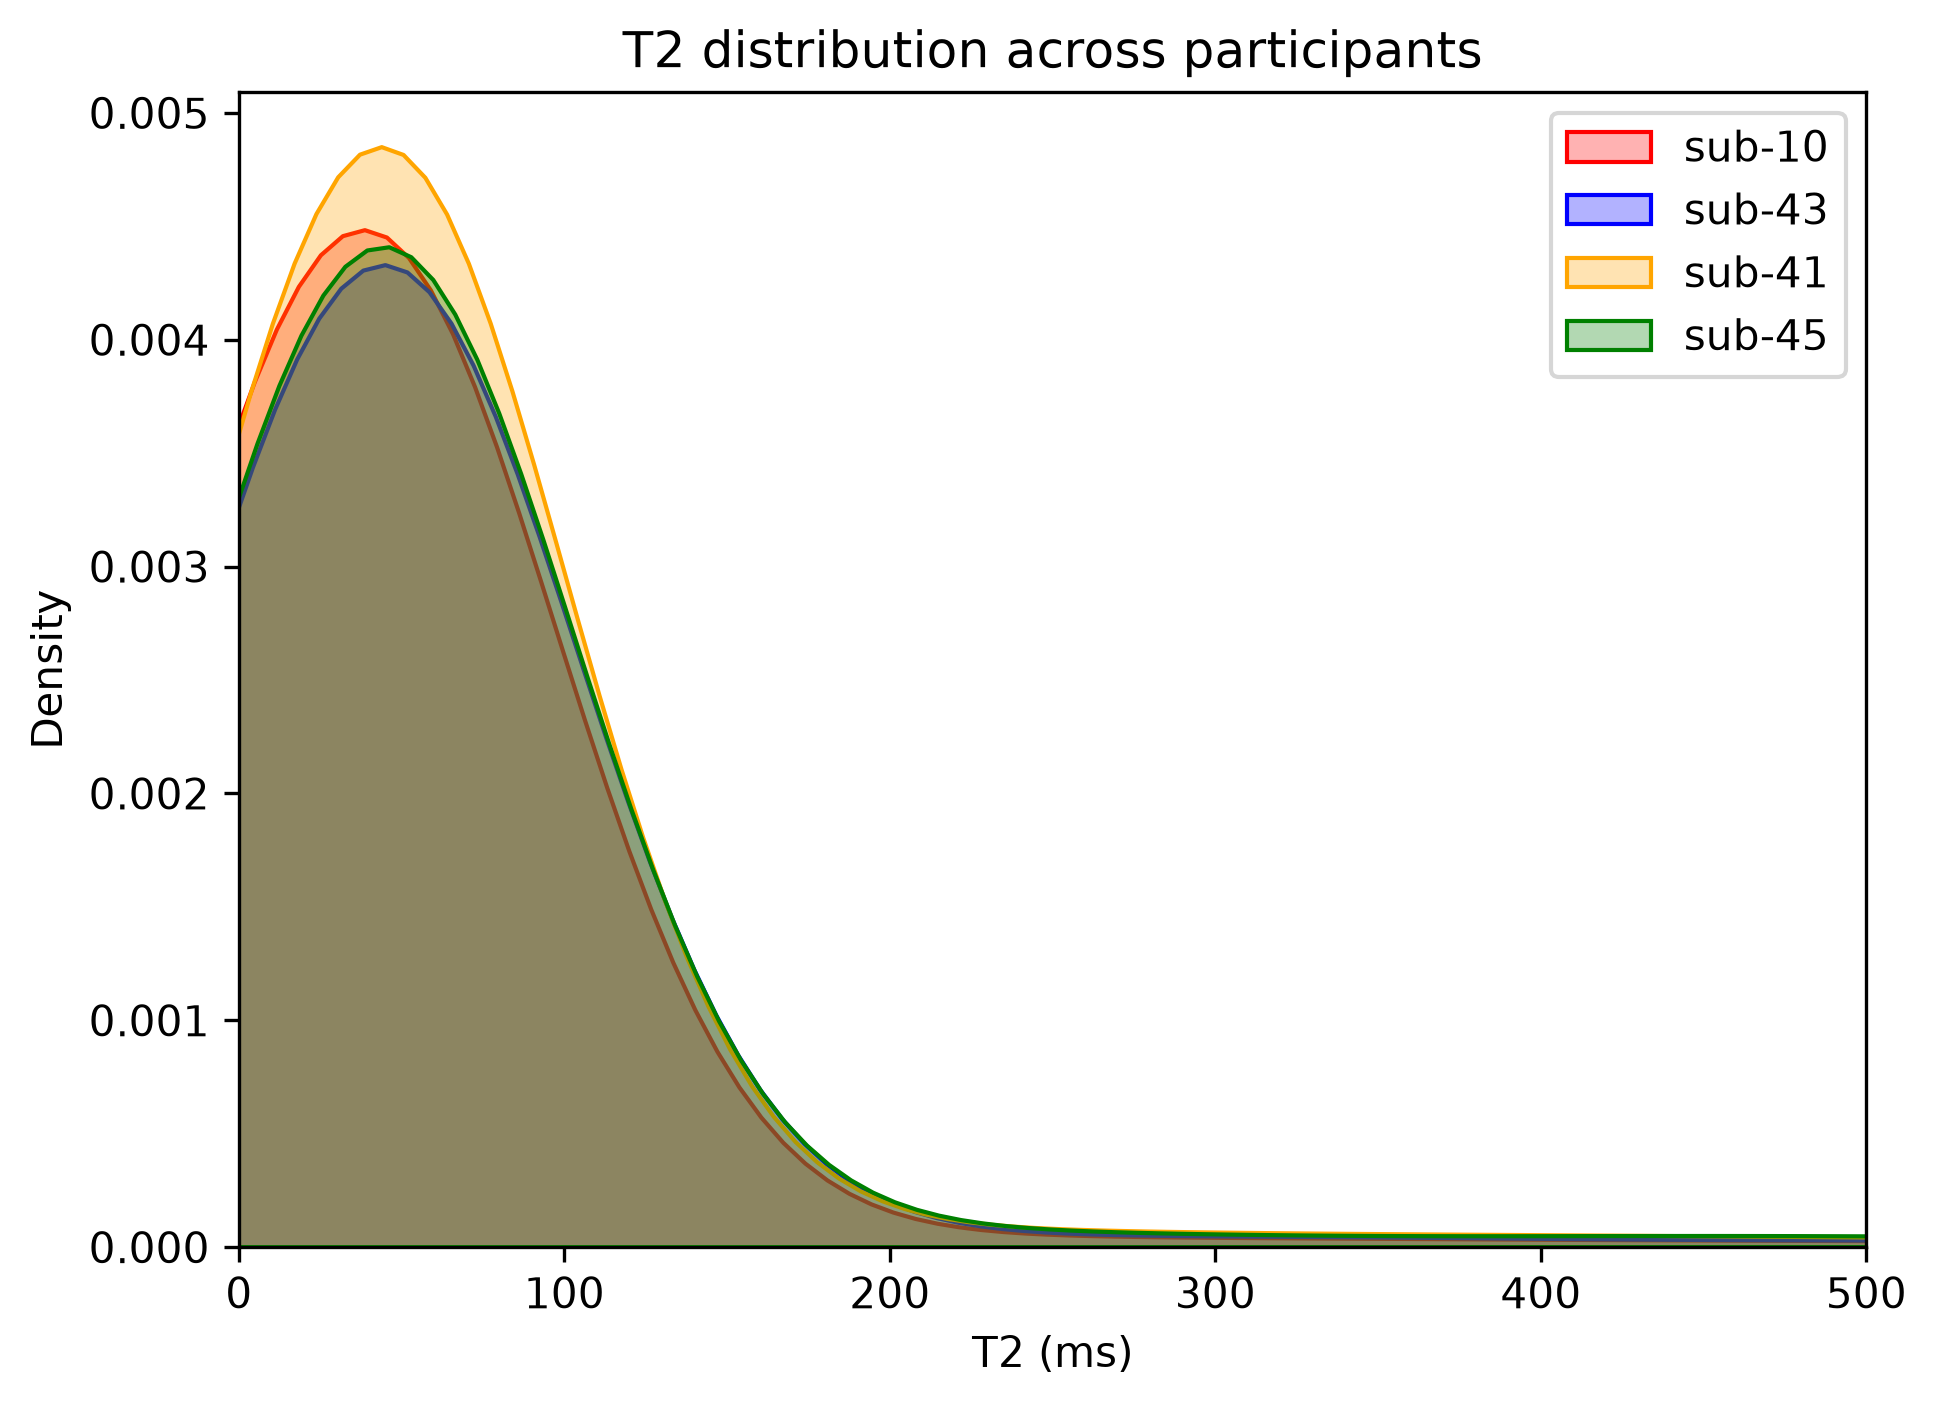

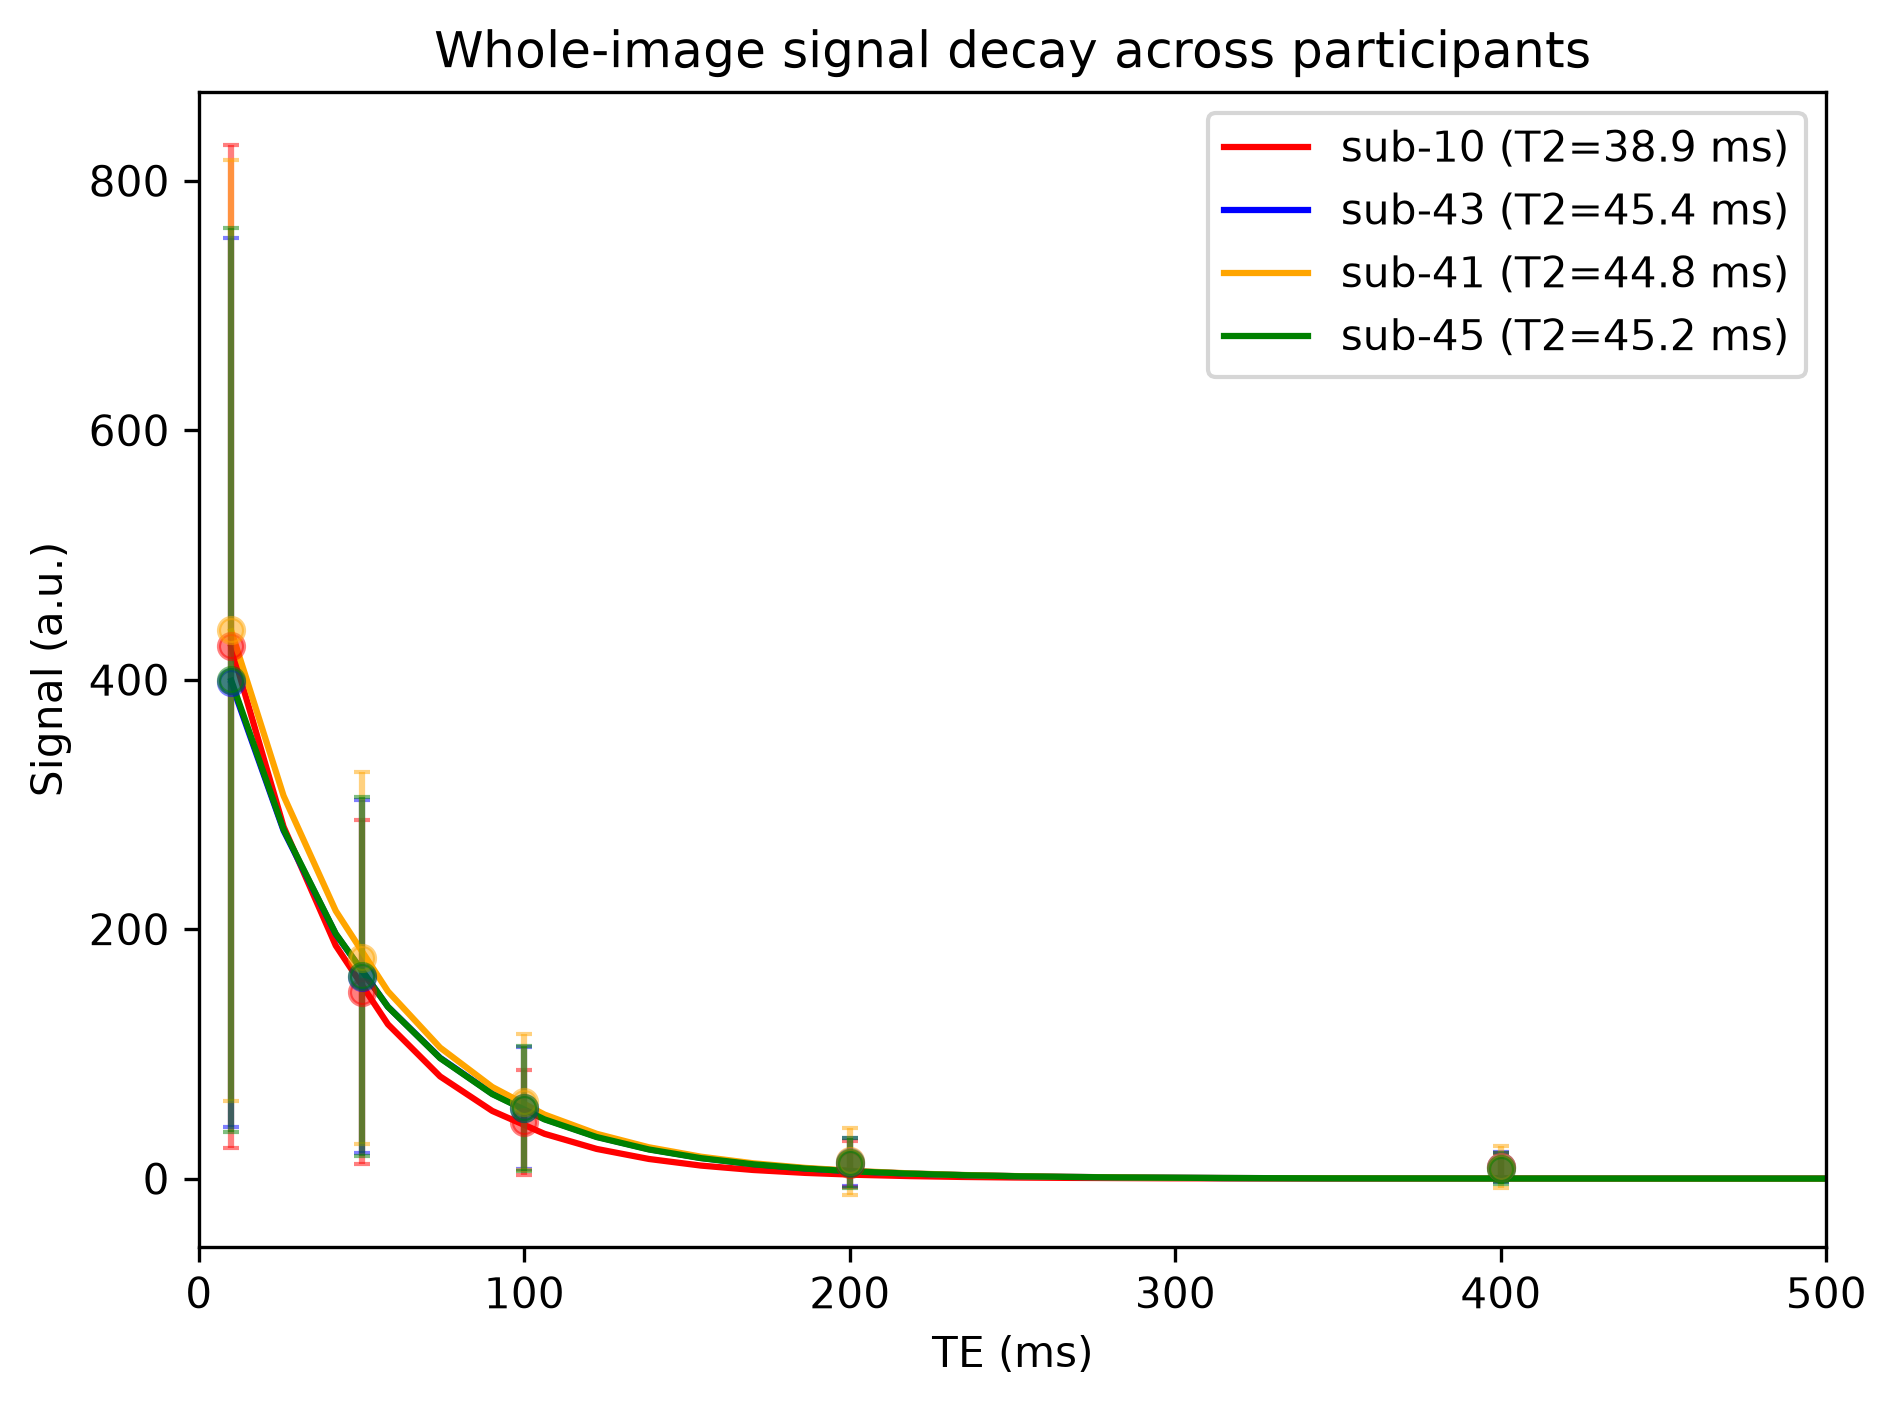


Done.


In [37]:
## Plots
# ── Colors ────────────────────────────────────────────────────────────────
# FIX: only 3 fixed colors were defined, so this breaks if you add a 4th
# participant to the `participants` dict above. Fall back to a colormap
# automatically if there are more than 3 subjects.
fixed_colors = ["red", "blue", "orange", "green"]
if len(results) <= len(fixed_colors):
    colors = fixed_colors[: len(results)]
else:
    colors = plt.cm.Set3(np.linspace(0, 1, len(results)))
 
# ── combined plot 1: T2 voxel distribution, all subjects overlaid ──────────
plt.figure(figsize=(7, 5), dpi=300)
 
for (subj, res), color in zip(results.items(), colors):
    # FIX: loop body must be indented, or Python raises an IndentationError
    sns.kdeplot(res["t2_values"], color=color, alpha=0.3, fill=True, label=subj)
 
plt.xlabel("T2 (ms)")
plt.ylabel("Density")
plt.title("T2 distribution across participants")
plt.legend()
plt.xlim(0, 500)
plt.show()
 
 
# ── combined plot 2: whole-image signal decay, all subjects overlaid ──────
TE_fine = np.linspace(TEs.min(), TEs.max(), 200)
 
plt.figure(figsize=(7, 5), dpi=300)
for (subj, res), color in zip(results.items(), colors):
    # FIX: `.astype(int)` on popt_mean would round S0 and T2 to whole numbers
    # before plotting the curve — just unpack the fitted values as they are.
    fit_curve = t2_decay(TE_fine, *res["popt_mean"])
    plt.errorbar(TEs, res["mean_signal"], yerr=res["std_signal"], fmt="o",
                 color=color, capsize=2, alpha=0.5)
    plt.plot(TE_fine, fit_curve, color=color, label=f"{subj} (T2={res['popt_mean'][1]:.1f} ms)")
 
plt.xlabel("TE (ms)")
plt.ylabel("Signal (a.u.)")
plt.title("Whole-image signal decay across participants")
plt.legend()
plt.xlim(0, 500)
plt.show()
print("\nDone.")


# Computing T1w map  - DOES NOT WORK
-------------------------------

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
from scipy.optimize import curve_fit


# ── inversion-recovery model ──
# Mirrors the MATLAB FF(p,x): p(1)*(1 - 2*exp(-x/p(2))), with the abs() applied
# only for magnitude data (no negative values) — same branch as bDoAbs in the .m file.
def t1_invrec_abs(TI, S0, T1):
    return (S0 * (1 - 2 * np.exp(-TI / T1)))


def t1_invrec_signed(TI, S0, T1):
    return S0 * (1 - 2 * np.exp(-TI / T1))


# ── participants ──
# dict of {label: path_to_4D_nifti}. Last dimension must be inversion time (TI).
participants = {
    "sub-10": r"/home/malberti/wks14/temp/FF_DWI_Drift/rawdata/sub-10/ses-01/T1w/sub-10_th_tse_TI.nii",
    "sub-41": r"/home/malberti/Unix_Folders/ESMRMB2026_Manfredi/sub-41/rh_se_ms_TI/sub-41_rh_tse_TI.nii",
    # "sub-XX": r"/path/to/sub-XX_file.nii",
}

TIs = np.array([25, 100, 200, 400, 800, 1600, 3200, 6400, 10000], dtype=float)  # seconds — must match 4th-dim order and units below
mask_path = None  # set to a path if you have a shared/explicit mask; else thresholds on mean signal per subject
out_dir_root = "/home/malberti/Unix_Folders/ESMRMB2026_Manfredi/group_T1_analysis"
os.makedirs(out_dir_root, exist_ok=True)

# start values / bounds — same defaults as the MATLAB version's x0=[.15, 1], lb=[0,0], ub=[2,2]
lb = [2.0, 2.0]
ub = [8.0, 8.0]

results = {}  # collect per-subject outputs for the combined plots at the end

for subj, nifti_path in participants.items():
    print(f"\n=== Processing {subj} ===")
    out_dir = os.path.join(out_dir_root, subj)
    os.makedirs(out_dir, exist_ok=True)

    # ── load data ──
    img = nib.load(nifti_path)
    data = img.get_fdata()  # (X, Y, Z, n_TI)
    affine = img.affine
    print(f"Loaded data with shape {data.shape}, {len(TIs)} TIs")

    # magnitude vs. signed data — same check as MATLAB's "any(A(:)<0)"
    use_abs = not np.any(data < 0)
    t1_invrec = t1_invrec_abs if use_abs else t1_invrec_signed
    print(f"  Using {'abs-value' if use_abs else 'signed'} model")

    if subj =="sub-10": 
            mask_path = r"/home/malberti/wks14/temp/FF_DWI_Drift/rawdata/sub-10/ses-01/T2w/sub-10_brain_mask.nii"
    else: 
        mask_path = r"/home/malberti/wks14/temp/FF_DWI_Drift/derivatives/sub-35/ses-01/dwi/eddy/sub-35_ses-01_unwarped_mask.nii"  # set to a path if you have a shared/explicit mask; else thresholds on mean signal per subject
        if mask_path is not None:   
            mask_img = nib.load(mask_path)
            # the mask covers the whole brain but this data is only a slab (smaller FOV,
            # possibly different affine), so it must be resampled onto the data's grid
            # before it can be used to index data — shapes/affines won't line up otherwise.
            from nilearn.image import resample_to_img
            mask_resampled = resample_to_img(mask_img, img, interpolation="nearest", force_resample=True, copy_header=True)
            mask = mask_resampled.get_fdata() > 0
        else:
            mask = data.mean(axis=-1) > 0  # 3D mask, one value per voxel across all echoes

    voxel_indices = np.argwhere(mask)
    n_voxels = len(voxel_indices)
    print(f"Fitting {n_voxels} voxels (nonlinear, voxel-by-voxel)")

    # ── nonlinear fit, voxel by voxel ─
    S0_map = np.full(data.shape[:3], np.nan, dtype=np.float32)
    T1_map = np.full(data.shape[:3], np.nan, dtype=np.float32)
    n_failed = 0

    for i, (x, y, z) in enumerate(voxel_indices):
        voxel_signal = data[x, y, z, :]
        popt, _ = curve_fit(t1_invrec, TIs, voxel_signal, p0=None ,bounds=(lb, ub))
        S0_map[x, y, z] = popt[0]
        T1_map[x, y, z] = popt[1]


    print(f"  {n_failed}/{n_voxels} voxels failed to converge")
    print(f"  Median T1 = {np.nanmedian(T1_map[mask]):.3f} s")

    nib.save(nib.Nifti1Image(S0_map, affine), os.path.join(out_dir, "S0_map.nii.gz"))
    nib.save(nib.Nifti1Image(T1_map, affine), os.path.join(out_dir, "T1_map.nii.gz"))

    # ── whole-image mean signal recovery vs TI, with fitted curve ──
    t1_values = T1_map[mask]
    t1_values = t1_values[~np.isnan(t1_values)]

    mean_signal = data[mask].mean(axis=0)  # (n_TI,) mean over all masked voxels, one point per TI
    std_signal = data[mask].std(axis=0)

    p0_mean = [np.max(np.abs(mean_signal)), np.mean(t1_values)]
    popt_mean, _ = curve_fit(t1_invrec, TIs, mean_signal, p0=None,bounds=(lb, ub))

    # store everything needed to overlay this subject on the combined plots below
    results[subj] = {
        "t1_values": t1_values,
        "mean_signal": mean_signal,
        "std_signal": std_signal,
        "popt_mean": popt_mean,
        "model": t1_invrec,
    }


=== Processing sub-10 ===
Loaded data with shape (160, 160, 1, 9), 9 TIs
  Using signed model
Fitting 2426681 voxels (nonlinear, voxel-by-voxel)


IndexError: index 13 is out of bounds for axis 2 with size 1

/tmp/ipykernel_124247/2253562301.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


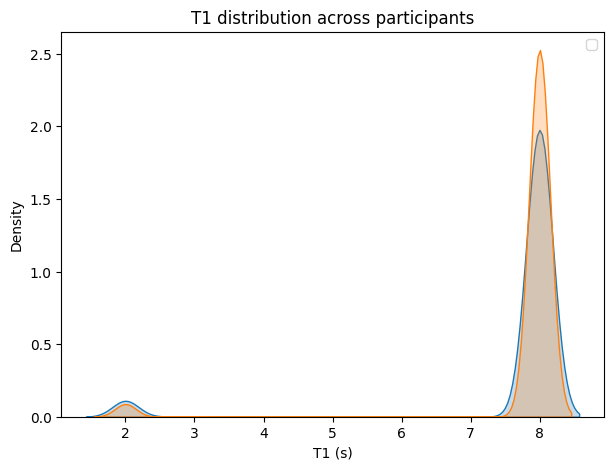

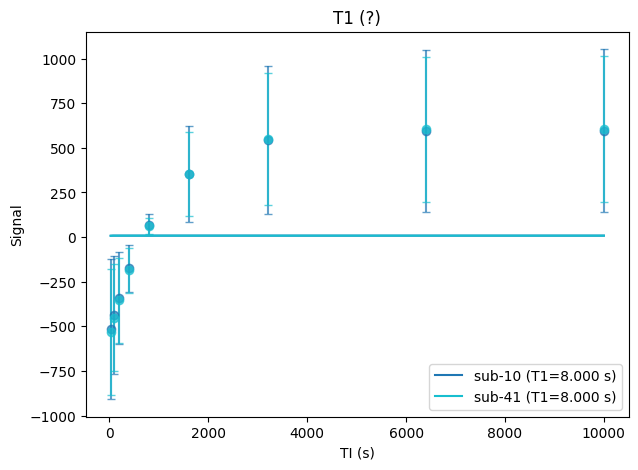

In [ ]:
# ── combined plot 1: T1 voxel distribution, all subjects overlaid ──
plt.figure(figsize=(7, 5))
for subj, res in results.items():
    sns.kdeplot(res["t1_values"], fill=True)
plt.xlabel("T1 (s)")
plt.ylabel("Density")
plt.title("T1 distribution across participants")
plt.legend()
plt.show()

# ── combined plot 2: whole-image signal recovery, all subjects overlaid ──
TI_fine = np.linspace(TIs.min(), TIs.max(), 200)
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))

plt.figure(figsize=(7, 5))
for (subj, res), color in zip(results.items(), colors):
    fit_curve = res["model"](TI_fine, *res["popt_mean"])
    plt.errorbar(TIs, res["mean_signal"], yerr=res["std_signal"], fmt="o",
                 color=color, capsize=3, alpha=0.7)
    plt.plot(TI_fine, fit_curve, color=color,
             label=f"{subj} (T1={res['popt_mean'][1]:.3f} s)")
plt.xlabel("TI (s)")
plt.ylabel("Signal")
plt.title("T1 (?)")
plt.legend()
plt.show()